In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [4]:
logon  = pd.read_csv('logon.csv')
device = pd.read_csv('device.csv')

# Parse datetime
logon['datetime']  = pd.to_datetime(logon['date'])
device['datetime'] = pd.to_datetime(device['date'])

logon['hour']        = logon['datetime'].dt.hour
logon['date_only']   = logon['datetime'].dt.date
logon['off_hours']   = ((logon['hour'] < 9) | (logon['hour'] > 18)).astype(int)

device['date_only']  = device['datetime'].dt.date

# Separate logon/logoff
logon_in  = logon[logon['activity'] == 'Logon']
logon_out = logon[logon['activity'] == 'Logoff']

# Session count per user per day
session_counts = logon_in.groupby(['user','date_only']).size().reset_index(name='session_count')

# Off-hours logons per user per day
off_hours_agg = logon_in.groupby(['user','date_only'])['off_hours'].max().reset_index()

# First login hour per user per day
first_login = logon_in.groupby(['user','date_only'])['hour'].min().reset_index(name='login_hour')

# Failed logons (logon without matching logoff — rough proxy)
total_logons  = logon[logon['activity']=='Logon'].groupby(['user','date_only']).size().reset_index(name='total_logons')
total_logoffs = logon[logon['activity']=='Logoff'].groupby(['user','date_only']).size().reset_index(name='total_logoffs')

# Device connects per user per day
device_counts = device.groupby(['user','date_only']).size().reset_index(name='device_connects')

# Unique PCs used per day
unique_pcs = logon_in.groupby(['user','date_only'])['pc'].nunique().reset_index(name='unique_pcs')

# Merge everything
df = session_counts \
    .merge(off_hours_agg,  on=['user','date_only'], how='left') \
    .merge(first_login,    on=['user','date_only'], how='left') \
    .merge(total_logons,   on=['user','date_only'], how='left') \
    .merge(total_logoffs,  on=['user','date_only'], how='left') \
    .merge(device_counts,  on=['user','date_only'], how='left') \
    .merge(unique_pcs,     on=['user','date_only'], how='left')

df.fillna(0, inplace=True)

# Failed auth proxy: logons without logoffs
df['failed_auth_attempts'] = (df['total_logons'] - df['total_logoffs']).clip(lower=0)
df.drop(columns=['total_logons','total_logoffs'], inplace=True)

df['is_anomaly'] = 0  # ground truth — update below if you have labels

print(df.shape)
print(df.head())
print(df.columns.tolist())
feature_cols = ['session_count', 'off_hours', 'login_hour',
                'device_connects', 'unique_pcs', 'failed_auth_attempts']

# Verify all cols exist
print([c for c in feature_cols if c not in df.columns])  # should print []

(1393129, 9)
      user   date_only  session_count  off_hours  login_hour  device_connects  \
0  AAB0162  2010-01-04              1          1           7              0.0   
1  AAB0162  2010-01-05              1          1           7              0.0   
2  AAB0162  2010-01-06              1          1           7              0.0   
3  AAB0162  2010-01-07              1          1           7              0.0   
4  AAB0162  2010-01-08              1          1           7              0.0   

   unique_pcs  failed_auth_attempts  is_anomaly  
0           1                     0           0  
1           1                     0           0  
2           1                     0           0  
3           1                     0           0  
4           1                     0           0  
['user', 'date_only', 'session_count', 'off_hours', 'login_hour', 'device_connects', 'unique_pcs', 'failed_auth_attempts', 'is_anomaly']
[]


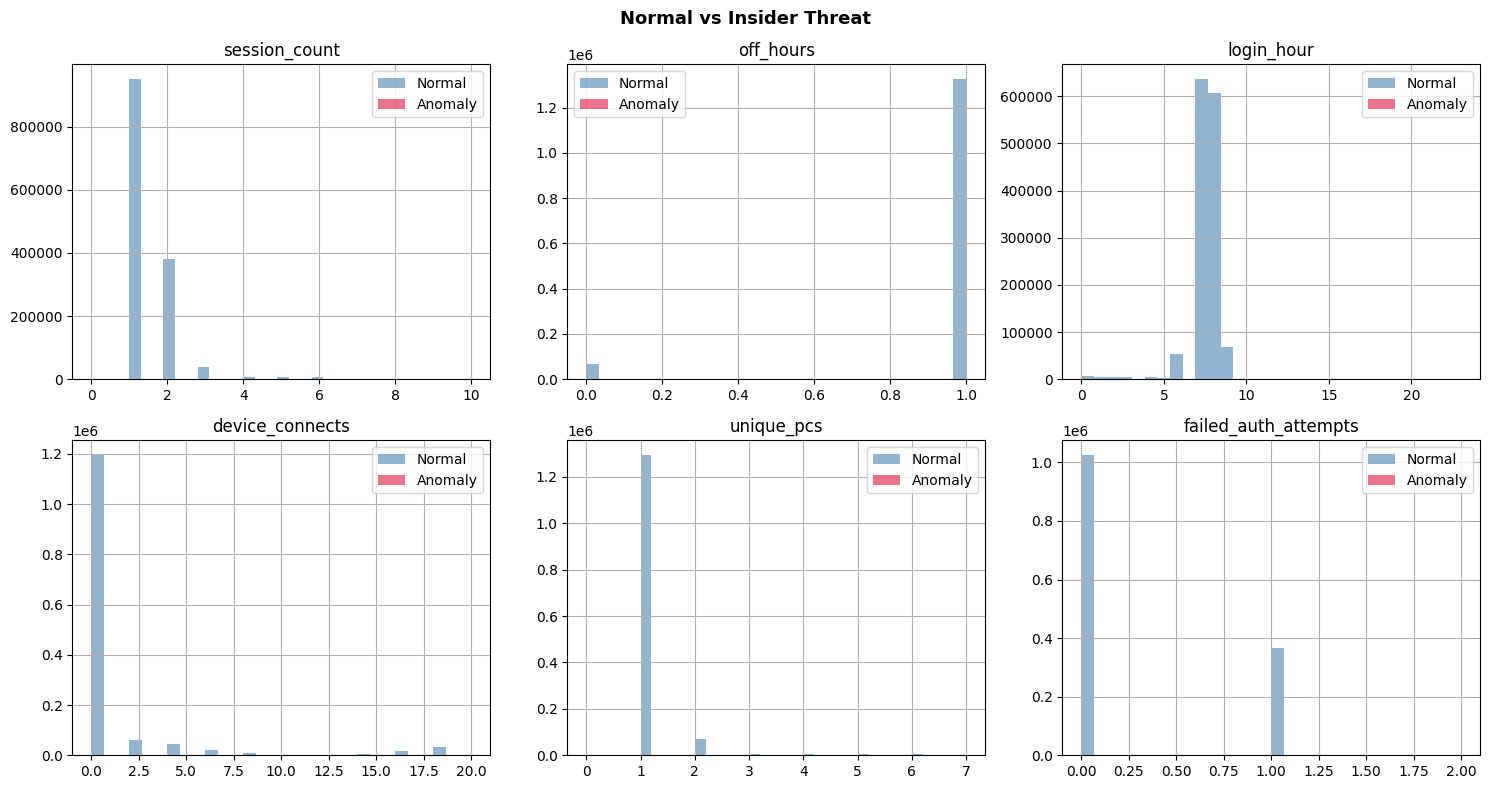

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), feature_cols[:6]):
    df[df['is_anomaly']==0][feat].hist(ax=ax, bins=30, alpha=0.6, color='steelblue', label='Normal')
    df[df['is_anomaly']==1][feat].hist(ax=ax, bins=30, alpha=0.6, color='crimson', label='Anomaly')
    ax.set_title(feat)
    ax.legend()
plt.suptitle('Normal vs Insider Threat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
feature_cols = ['session_count', 'off_hours', 'login_hour',
                'device_connects', 'unique_pcs', 'failed_auth_attempts']

all_data = df[feature_cols].values

scaler = MinMaxScaler()
all_scaled = scaler.fit_transform(all_data)

split = int(len(all_scaled) * 0.85)
X_train = all_scaled[:split].reshape(-1, 1, len(feature_cols))
X_val   = all_scaled[split:].reshape(-1, 1, len(feature_cols))

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Train: (1184159, 1, 6) | Val: (208970, 1, 6)


In [7]:
n_features = len(feature_cols)

inp = Input(shape=(1, n_features))
x = LSTM(64, activation='relu', return_sequences=True)(inp)
x = LSTM(32, activation='relu', return_sequences=False)(x)
x = RepeatVector(1)(x)
x = LSTM(32, activation='relu', return_sequences=True)(x)
x = LSTM(64, activation='relu', return_sequences=True)(x)
out = TimeDistributed(Dense(n_features))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1, 6)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 1, 64)               │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 1, 32)               │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 1, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 1, 6)                │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,134 (250.52 KB)

 Trainable params: 64,134 (250.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - loss: 0.0175 - val_loss: 0.0116
Epoch 2/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 98s 3ms/step - loss: 0.0115 - val_loss: 0.0103
Epoch 3/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - loss: 0.0102 - val_loss: 0.0100
Epoch 4/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 116s 3ms/step - loss: 0.0048 - val_loss: 8.7854e-04
Epoch 5/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 105s 3ms/step - loss: 7.3696e-04 - val_loss: 5.7488e-04
Epoch 6/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 103s 3ms/step - loss: 6.2507e-04 - val_loss: 5.6566e-04
Epoch 7/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 98s 3ms/step - loss: 5.6692e-04 - val_loss: 5.7891e-04
Epoch 8/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 107s 3ms/step - loss: 5.2522e-04 - val_loss: 5.4960e-04
Epoch 9/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 109s 3ms/step - loss: 4.9388e-04 - val_loss: 4.4157e-04
Epoch 10/100
37005/37005 ━━━━━━━━━━━━━━━━━━━━ 100s 3ms/step - loss: 4.6151e-04 - val_loss: 5.9624e-04
Epoch 11/100
37005/

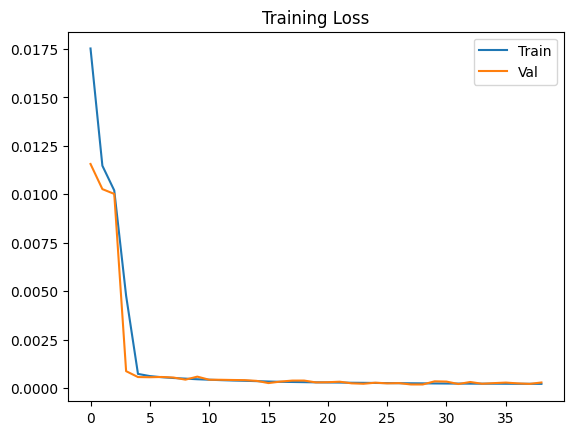

In [8]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[es],
    verbose=1
)

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Training Loss'); plt.legend(); plt.show()

In [9]:
train_recon = model.predict(X_train, verbose=0)
train_mae   = np.mean(np.abs(X_train - train_recon), axis=(1,2))

THRESHOLD = np.mean(train_mae) + 3 * np.std(train_mae)
print(f"Threshold: {THRESHOLD:.4f}")

Threshold: 0.0017


In [10]:
all_3d    = all_scaled.reshape(-1, 1, n_features)
all_recon = model.predict(all_3d, verbose=0)
all_mae   = np.mean(np.abs(all_3d - all_recon), axis=(1,2))

df['recon_error']  = all_mae
df['pred_anomaly'] = (all_mae > THRESHOLD).astype(int)

print(f"Total flagged as anomaly : {df['pred_anomaly'].sum()}")
print(f"Anomaly rate             : {df['pred_anomaly'].mean()*100:.2f}%")
print(df[df['pred_anomaly']==1][feature_cols + ['recon_error']].head(10))

Total flagged as anomaly : 5354
Anomaly rate             : 0.38%
      session_count  off_hours  login_hour  device_connects  unique_pcs  \
864               3          1           7              0.0           1   
933               3          1           8              0.0           1   
1010              3          1           7              0.0           1   
1017              3          1           8              6.0           1   
1050              3          1           7              4.0           1   
8230              3          1           8              0.0           1   
8801              2          1           9              0.0           2   
8904              2          1           9              0.0           2   
9553              4          1           0             14.0           1   
9595              3          1           8             14.0           1   

      failed_auth_attempts  recon_error  
864                      2     0.003341  
933                      

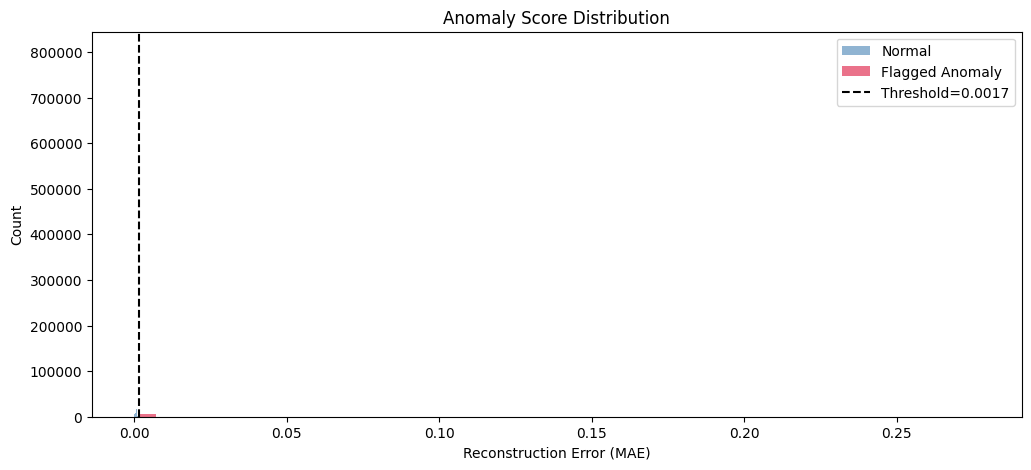

In [11]:
plt.figure(figsize=(12,5))
plt.hist(df[df['pred_anomaly']==0]['recon_error'],
         bins=50, alpha=0.6, color='steelblue', label='Normal')
plt.hist(df[df['pred_anomaly']==1]['recon_error'],
         bins=50, alpha=0.6, color='crimson', label='Flagged Anomaly')
plt.axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold={THRESHOLD:.4f}')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Count')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.show()

In [12]:
top_threats = df[df['pred_anomaly']==1] \
    .sort_values('recon_error', ascending=False) \
    .head(20)[['user', 'date_only'] + feature_cols + ['recon_error']]

print("Top 20 Flagged Sessions:")
print(top_threats.to_string())

Top 20 Flagged Sessions:
            user   date_only  session_count  off_hours  login_hour  device_connects  unique_pcs  failed_auth_attempts  recon_error
927466   MPH0153  2011-02-07              1          1          23              0.0           1                     0     0.277134
133665   BBW0594  2010-04-26              2          1          13              8.0           1                     1     0.224666
1049517  PTS2487  2010-06-01              3          0           9              0.0           1                     2     0.100086
601345   IKP1047  2010-06-23              1          0          18              2.0           1                     0     0.069673
1110211  RLK3490  2010-10-21              1          0          17              0.0           1                     0     0.064989
1282067  UMB0055  2010-06-07              1          0          15              4.0           1                     0     0.046489
1198667  SMS2452  2010-10-20              1          0    

In [13]:
def spcbac_alert(session: dict):
    inp = scaler.transform(pd.DataFrame([session])[feature_cols]).reshape(1,1,n_features)
    err = np.mean(np.abs(inp - model.predict(inp, verbose=0)))
    flag = err > THRESHOLD
    print(f"Recon Error: {err:.4f} | {'INSIDER THREAT — revoke blockchain access' if flag else 'Normal'}")
    return flag

# Test with suspicious session
spcbac_alert({
    'session_count': 15,
    'off_hours': 1,
    'login_hour': 2,
    'device_connects': 10,
    'unique_pcs': 8,
    'failed_auth_attempts': 6
})

Recon Error: 0.9394 | INSIDER THREAT — revoke blockchain access


np.True_

In [14]:
model.save('gap2_model.keras')
import joblib
joblib.dump(scaler, 'gap2_scaler.pkl')

['gap2_scaler.pkl']